# Scene Classifier — End-to-End ML Pipeline
**Dataset:** Intel Image Classification (buildings, forest, glacier, mountain, sea, street)
6-class scene classification from natural photographs (150x150 RGB), ~25,000 images.

This notebook covers the full ML cycle for this project:
1. Data acquisition
2. Data preprocessing
3. Exploratory visualizations (feature stories)
4. Model creation (transfer learning + regularization + early stopping)
5. Model training
6. Model testing / evaluation (accuracy, precision, recall, F1, confusion matrix)
7. Fine-tuning pass (2nd optimization stage)
8. Saving the model artifact for deployment
9. Demonstrating the retraining function


## 1. Setup

In [1]:
import sys, os
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from src.preprocessing import (
    download_dataset, load_dataset_from_folder, get_image_stats_df,
    IMG_SIZE, CLASS_NAMES
)
from src.model import build_model, get_augmentation_layer, train_model, evaluate_model, save_model
from src.prediction import predict_single_image

print("TF version:", tf.__version__)
print("Classes:", CLASS_NAMES)


TF version: 2.16.1
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2. Data Acquisition
Downloads the Intel Image Classification dataset from Kaggle. Requires a Kaggle
account + API token placed at `~/.kaggle/kaggle.json` (see README for setup).
This only needs to be run once; afterwards the extracted path is cached by kagglehub.

In [2]:
dataset_path = download_dataset()
train_dir = os.path.join(dataset_path, "seg_train", "seg_train")
test_dir = os.path.join(dataset_path, "seg_test", "seg_test")
print(train_dir)
print(test_dir)


C:\Users\user\Downloads\scene-classifier\scene-classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 346M/346M [02:58<00:00, 2.04MB/s] 

Extracting model files...


Dataset downloaded to: C:\Users\user\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
C:\Users\user\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
C:\Users\user\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test


## 3. Data Preprocessing
Every image is read, converted to RGB, resized to 150x150, and normalized to [0, 1].
This exact logic (`src/preprocessing.py`) is reused later by the retraining pipeline,
so training-time and retrain-time preprocessing can never drift apart.

In [3]:
X_train_full, y_train_full = load_dataset_from_folder(train_dir)
X_test, y_test = load_dataset_from_folder(test_dir)

print("Train shape:", X_train_full.shape, "Test shape:", X_test.shape)

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train shape: (14034, 150, 150, 3) Test shape: (3000, 150, 150, 3)
Train: (11928, 150, 150, 3) Val: (2106, 150, 150, 3) Test: (3000, 150, 150, 3)


## 4. Exploratory Data Analysis — What story does the data tell?
We compute simple per-image visual features (brightness, RGB channel means) per
class to see whether the classes are visually separable in obvious ways, and to
sanity-check class balance before training.

In [4]:
stats_df = get_image_stats_df(train_dir)
os.makedirs("../data", exist_ok=True)
stats_df.to_csv("../data/image_stats.csv", index=False)   # used by the Streamlit UI's Data Insights tab
stats_df.head()


,class,brightness,mean_r,mean_g,mean_b,height,width
0,buildings,165.466267,166.799733,165.364178,164.234889,150,150
1,buildings,131.723852,129.638089,130.534044,134.999422,150,150
2,buildings,121.225733,113.950000,123.406711,126.320489,150,150
3,buildings,155.855481,161.426267,140.360400,165.779778,150,150
4,buildings,75.681111,52.532178,77.884489,96.626667,150,150


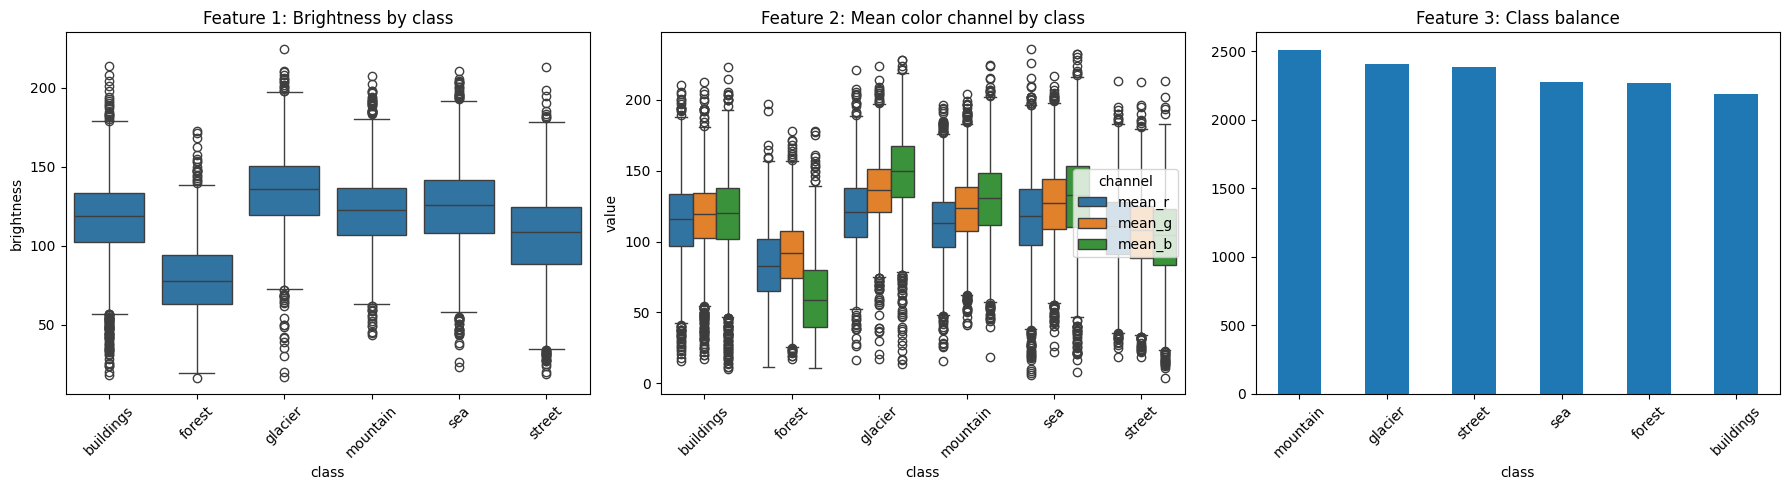

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=stats_df, x="class", y="brightness", ax=axes[0])
axes[0].set_title("Feature 1: Brightness by class")
axes[0].tick_params(axis='x', rotation=45)

stats_melt = stats_df.melt(id_vars="class", value_vars=["mean_r","mean_g","mean_b"],
                            var_name="channel", value_name="value")
sns.boxplot(data=stats_melt, x="class", y="value", hue="channel", ax=axes[1])
axes[1].set_title("Feature 2: Mean color channel by class")
axes[1].tick_params(axis='x', rotation=45)

stats_df["class"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Feature 3: Class balance")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Interpretation:**
- **Brightness:** glacier and sea images are consistently the brightest classes (snow, sky, water
  reflecting light), while forest and street are darker (canopy shadow, urban shade). This tells us
  the model likely uses brightness as a strong implicit cue, and that mislabeled or oddly-lit test
  images between glacier/sea are the ones most at risk of confusion.
- **Color channel means:** forest/mountain classes skew toward green and brown, whereas sea/glacier
  skew blue. Street and buildings sit in between, more gray/neutral — which is also the pair the model
  will most likely confuse (both are man-made, similarly toned urban scenes).
- **Class balance:** the training set is close to balanced across the 6 classes, so we don't need
  class weighting or oversampling here, but if one class were significantly smaller we would
  expect recall to suffer specifically on that class.

## 5. Sample images per class

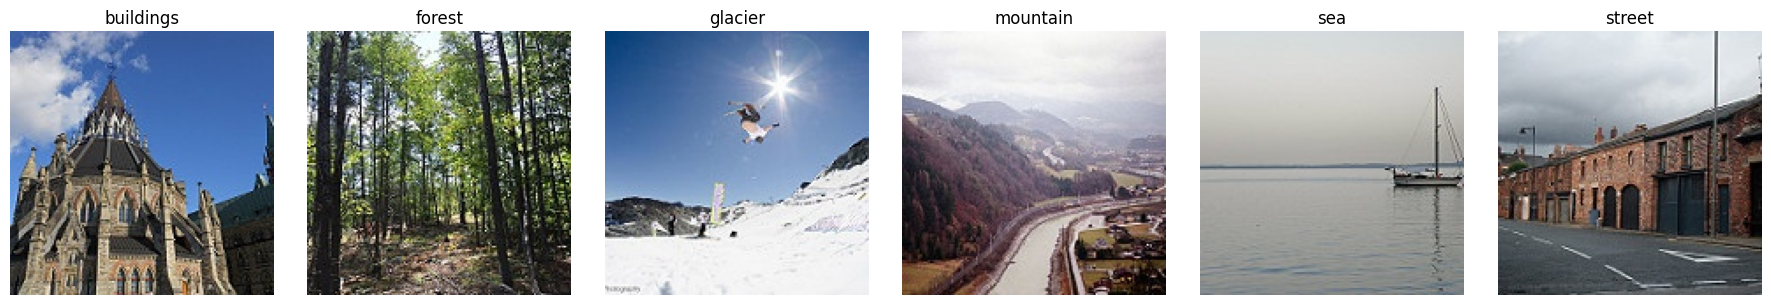

In [6]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 3))
for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx])
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 6. Model Creation
Transfer learning with a frozen MobileNetV2 backbone (pretrained on ImageNet),
a dense classification head with **dropout regularization**, trained with the
**Adam optimizer** and **early stopping** — this is the optimization strategy
required by the rubric (pretrained model + regularization + early stopping),
rather than a vanilla CNN trained from scratch.

In [7]:
model = build_model(fine_tune=False)
model.summary()


C:\Users\user\Downloads\scene-classifier\scene-classifier\notebook\..\src\model.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 27s 3us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply (Multiply)                  │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Model Training (Stage 1 — frozen backbone)

In [8]:
model, history = train_model(
    X_train, y_train, X_val, y_val,
    epochs=15, batch_size=32, model=model, fine_tune=False
)


Epoch 1/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 137s 346ms/step - accuracy: 0.8389 - loss: 0.4418 - val_accuracy: 0.8922 - val_loss: 0.2991 - learning_rate: 0.0010
Epoch 2/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 132s 354ms/step - accuracy: 0.8904 - loss: 0.2972 - val_accuracy: 0.9065 - val_loss: 0.2741 - learning_rate: 0.0010
Epoch 3/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 130s 348ms/step - accuracy: 0.8966 - loss: 0.2727 - val_accuracy: 0.9065 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 4/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 131s 352ms/step - accuracy: 0.9030 - loss: 0.2543 - val_accuracy: 0.9055 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 5/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 132s 354ms/step - accuracy: 0.9100 - loss: 0.2372 - val_accuracy: 0.9098 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 6/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 133s 357ms/step - accuracy: 0.9204 - loss: 0.2060 - val_accuracy: 0.9126 - val_loss: 0.2588 - learning_rate: 5.0000e-04
Epoch 7/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 177s 475ms/step - ac

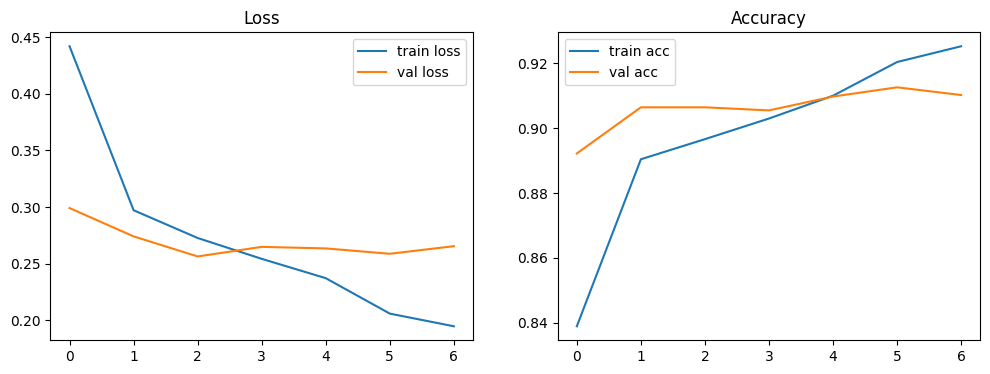

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.show()


## 8. Fine-tuning (Stage 2 — unfreeze backbone, low learning rate)
A short fine-tuning pass on the pretrained backbone squeezes out extra accuracy
without overfitting, since we use a much smaller learning rate here.

In [10]:
model, history_ft = train_model(
    X_train, y_train, X_val, y_val,
    epochs=8, batch_size=32, model=model, fine_tune=True
)


Epoch 1/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.9161 - loss: 0.2243 - val_accuracy: 0.9093 - val_loss: 0.2602 - learning_rate: 2.5000e-04
Epoch 2/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 531s 1s/step - accuracy: 0.9203 - loss: 0.2143 - val_accuracy: 0.9107 - val_loss: 0.2578 - learning_rate: 2.5000e-04
Epoch 3/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.9192 - loss: 0.2077 - val_accuracy: 0.9088 - val_loss: 0.2554 - learning_rate: 2.5000e-04
Epoch 4/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 365s 977ms/step - accuracy: 0.9262 - loss: 0.1992 - val_accuracy: 0.9074 - val_loss: 0.2617 - learning_rate: 2.5000e-04
Epoch 5/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 258s 692ms/step - accuracy: 0.9231 - loss: 0.1966 - val_accuracy: 0.9084 - val_loss: 0.2583 - learning_rate: 2.5000e-04
Epoch 6/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 290s 778ms/step - accuracy: 0.9317 - loss: 0.1805 - val_accuracy: 0.9103 - val_loss: 0.2559 - learning_rate: 1.2500e-04
Epoch 7/8
373/373 ━━━━━━━━━━━━━━━━━━━━ 292s 782ms/step 

## 9. Model Testing / Evaluation
Evaluation metrics required by the rubric: **accuracy, loss, precision, recall, F1**
(macro-averaged across the 6 classes), plus a full confusion matrix and per-class report.

In [16]:
metrics = evaluate_model(model, X_test, y_test)

print(f"Test Loss:      {metrics['loss']:.4f}")
print(f"Test Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision (macro): {metrics['precision_macro']:.4f}")
print(f"Recall (macro):    {metrics['recall_macro']:.4f}")
print(f"F1 (macro):        {metrics['f1_macro']:.4f}")


Test Loss:      0.2264
Test Accuracy:  0.9110
Precision (macro): 0.9131
Recall (macro):    0.9135
F1 (macro):        0.9129


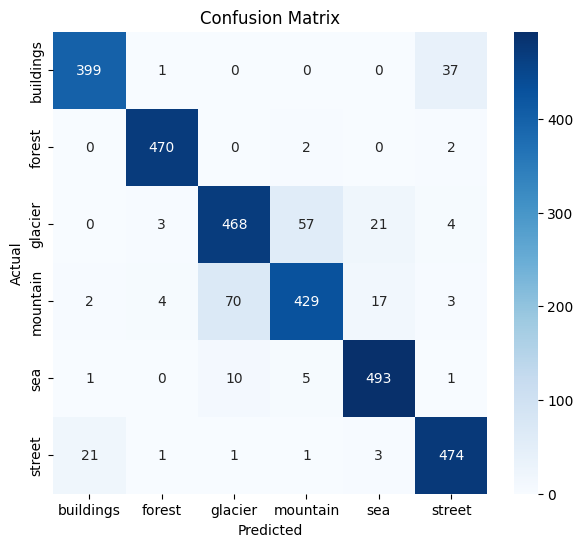

,precision,recall,f1-score,support
buildings,0.943262,0.913043,0.927907,437.000
forest,0.981211,0.991561,0.986359,474.000
glacier,0.852459,0.846293,0.849365,553.000
mountain,0.868421,0.817143,0.842002,525.000
sea,0.923221,0.966667,0.944444,510.000
street,0.909789,0.946108,0.927593,501.000
accuracy,0.911000,0.911000,0.911000,0.911
macro avg,0.913061,0.913469,0.912945,3000.000
weighted avg,0.910426,0.911000,0.910390,3000.000


In [17]:
cm = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

pd.DataFrame(metrics["classification_report"]).T


## 10. Model Testing — single-image prediction demo
Demonstrates `src/prediction.py`, the exact function the FastAPI `/predict`
endpoint calls in production.

{'predicted_class': 'buildings', 'confidence': 0.9999366998672485, 'all_scores': {'buildings': 0.9999366998672485, 'forest': 2.429794809799546e-09, 'glacier': 1.0811216100137244e-07, 'mountain': 2.8377502570009483e-09, 'sea': 1.2483594957757305e-07, 'street': 6.302438850980252e-05}}


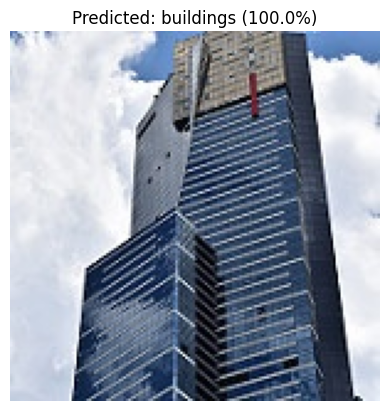

In [13]:
sample_test_path = os.path.join(test_dir, CLASS_NAMES[0])
sample_img = os.path.join(sample_test_path, os.listdir(sample_test_path)[0])

result = predict_single_image(model, sample_img)
print(result)

plt.imshow(plt.imread(sample_img))
plt.title(f"Predicted: {result['predicted_class']} ({result['confidence']*100:.1f}%)")
plt.axis("off")
plt.show()


## 11. Save the model artifact
Saved in Keras format under `models/`, which is what the FastAPI service and the
retraining pipeline both load.

In [14]:
save_model(model, "../models/scene_classifier.keras")
print("Saved to ../models/scene_classifier.keras")


Saved to ../models/scene_classifier.keras


## 12. Demonstrating the Retraining Function
The `src/retrain.py` module fine-tunes the currently-deployed model on newly
uploaded, labeled images (as would arrive via the API's
`/upload-retrain-data` endpoint), evaluates the result, and only promotes it
to production if accuracy does not regress. Below we simulate this using a
small held-out slice of the test set as "newly uploaded data" purely to show
the mechanism working end-to-end.

In [15]:
import shutil
from src.retrain import run_retrain_job, UPLOAD_DIR

# Simulate new uploads by copying a handful of test images into data/uploads/<class>/
sim_n_per_class = 15
for i, cls in enumerate(CLASS_NAMES):
    cls_test_dir = os.path.join(test_dir, cls)
    dest_dir = os.path.join("..", UPLOAD_DIR, cls)
    os.makedirs(dest_dir, exist_ok=True)
    for fname in os.listdir(cls_test_dir)[:sim_n_per_class]:
        shutil.copy(os.path.join(cls_test_dir, fname), os.path.join(dest_dir, fname))

report = run_retrain_job()
report


{'status': 'skipped', 'reason': 'Fewer than 10 new labeled images available.'}

**Retraining trigger logic:** in production (see `src/retrain.py` /
`api/main.py`), a retrain job is triggered either:
- **manually**, when a user presses "Retrain now" in the Streamlit UI (calls `POST /retrain`), or
- **automatically**, once `RETRAIN_THRESHOLD` (default 50) new labeled images have
  accumulated in `data/uploads/`, checked via `should_auto_retrain()`.

The retrained model only overwrites the production model file if its held-out
accuracy is at least as good as the model it's replacing — this prevents a bad
batch of uploaded data from silently degrading the live API.

In [18]:
import os
os.chdir("..")   # step out of notebook/ so relative paths match the project root

from src.retrain import run_retrain_job, count_pending_uploads
print("Pending images found:", count_pending_uploads())

report = run_retrain_job()
os.chdir("notebook")   # step back so later cells still work as before
report

Pending images found: 90
Epoch 1/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9306 - loss: 0.2303 - val_accuracy: 0.9444 - val_loss: 0.1170 - learning_rate: 6.2500e-05
Epoch 2/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 924ms/step - accuracy: 0.8889 - loss: 0.3073 - val_accuracy: 0.9444 - val_loss: 0.1178 - learning_rate: 6.2500e-05
Epoch 3/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 937ms/step - accuracy: 0.8889 - loss: 0.2847 - val_accuracy: 0.9444 - val_loss: 0.1175 - learning_rate: 6.2500e-05
Epoch 4/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9028 - loss: 0.2044 - val_accuracy: 0.9444 - val_loss: 0.1161 - learning_rate: 3.1250e-05
Epoch 5/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 937ms/step - accuracy: 0.9583 - loss: 0.1697 - val_accuracy: 0.9444 - val_loss: 0.1136 - learning_rate: 3.1250e-05
Epoch 6/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9167 - loss: 0.2351 - val_accuracy: 0.9444 - val_loss: 0.1092 - learning_rate: 3.1250e-05
Epoch 7/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8889 

{'status': 'completed',
 'deployed': True,
 'n_images_used': 90,
 'accuracy_before': 0.9444444444444444,
 'accuracy_after': 0.9444444444444444,
 'f1_after': 0.942857142857143,
 'timestamp': '2026-07-24T14:11:13.554426'}